Formulation du problème :

    Identifier les clients de Thera Bank ayant la plus forte probabilité d’accepter un prêt personnel, afin de cibler les campagnes marketing et d’améliorer le taux de conversion tout en réduisant les coûts.

2. Formulation les questions business :

Question principale

    Quels clients sont les plus susceptibles d'accepter un prêt personnel ?

Questions secondaires :

    Les clients à revenus élevés acceptent-ils davantage les prêts ?
    L'éducation influence-t-elle l'acceptation ?
    Les clients utilisant les services en ligne sont-ils plus susceptibles d'accepter ?
    La détention d'un certificat de dépôt est-elle associée à l'acceptation ?
    Les clients ayant déjà un prêt hypothécaire sont-ils plus susceptibles d'accepter ?
    L'âge influence-t-il la probabilité d'acceptation ?
    Les clients avec une famille plus nombreuse sont-ils plus réceptifs ?
    Quels profils de clients sont les plus intéressants pour le marketing ?

4. Étape 1 — Importation et découverte des données

In [1]:
import pandas as pd

df = pd.read_excel("D:/Projets/Projet_Bank_Taux_de_reconvertion/thera_bank.xlsx", sheet_name="Data", 
                   header=0, index_col=0)

df.head()

,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Education,Prêt_Hypothecaire,Accepte_Pret,Compte_Titre,Certificat_Depot,Services_Ligne,CreditCard
ID,,,,,,,,,,,,,
1,25,1,49000,91107,4,1600.0,Licence,0,Non,Oui,Non,Non,Non
2,45,19,34000,90089,3,1500.0,Licence,0,Non,Oui,Non,Non,Non
3,39,15,11000,94720,1,1000.0,Licence,0,Non,Non,Non,Non,Non
4,35,9,100000,94112,1,2700.0,Master,0,Non,Non,Non,Non,Non
5,35,8,45000,91330,4,1000.0,Master,0,Non,Non,Non,Non,Oui


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 1 to 5000
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Revenu              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   Depenses_Mensuelle  5000 non-null   float64
 6   Education           5000 non-null   str    
 7   Prêt_Hypothecaire   5000 non-null   int64  
 8   Accepte_Pret        5000 non-null   str    
 9   Compte_Titre        5000 non-null   str    
 10  Certificat_Depot    5000 non-null   str    
 11  Services_Ligne      5000 non-null   str    
 12  CreditCard          5000 non-null   str    
dtypes: float64(1), int64(6), str(6)
memory usage: 640.4 KB


,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Prêt_Hypothecaire
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.338400,20.104600,73774.200000,93152.503000,2.396400,1937.913333,56498.800000
std,11.463166,11.467954,46033.729321,2121.852197,1.147663,1747.666159,101713.802102
min,23.000000,-3.000000,8000.000000,9307.000000,1.000000,0.000000,0.000000
25%,35.000000,10.000000,39000.000000,91911.000000,1.000000,700.000000,0.000000
50%,45.000000,20.000000,64000.000000,93437.000000,2.000000,1500.000000,0.000000
75%,55.000000,30.000000,98000.000000,94608.000000,3.000000,2500.000000,101000.000000
max,67.000000,43.000000,224000.000000,96651.000000,4.000000,10000.000000,635000.000000


In [3]:
df.isnull().sum()

Age                   0
Experience            0
Revenu                0
ZIP Code              0
Family                0
Depenses_Mensuelle    0
Education             0
Prêt_Hypothecaire     0
Accepte_Pret          0
Compte_Titre          0
Certificat_Depot      0
Services_Ligne        0
CreditCard            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["Accepte_Pret"].value_counts()

Accepte_Pret
Non    4520
Oui     480
Name: count, dtype: int64

In [12]:
df[df["Age"] <= 0]

,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Education,Prêt_Hypothecaire,Accepte_Pret,Compte_Titre,Certificat_Depot,Services_Ligne,CreditCard
ID,,,,,,,,,,,,,


In [9]:
df[df["Revenu"] < 0]

,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Education,Prêt_Hypothecaire,Accepte_Pret,Compte_Titre,Certificat_Depot,Services_Ligne,CreditCard
ID,,,,,,,,,,,,,


In [13]:
df[df["Experience"] < 0]

,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Education,Prêt_Hypothecaire,Accepte_Pret,Compte_Titre,Certificat_Depot,Services_Ligne,CreditCard
ID,,,,,,,,,,,,,
90,25,-1,113000,94303,4,2300.000000,Formation professionnelle,0,Non,Non,Non,Non,Oui
227,24,-1,39000,94085,2,1700.000000,Master,0,Non,Non,Non,Non,Non
316,24,-2,51000,90630,3,300.000000,Formation professionnelle,0,Non,Non,Non,Oui,Non
452,28,-2,48000,94132,2,1750.000000,Formation professionnelle,89000,Non,Non,Non,Oui,Non
525,24,-1,75000,93014,4,200.000000,Licence,0,Non,Non,Non,Oui,Non
537,25,-1,43000,92173,3,2400.000000,Master,176000,Non,Non,Non,Oui,Non
541,25,-1,109000,94010,4,2300.000000,Formation professionnelle,314000,Non,Non,Non,Oui,Non
577,25,-1,48000,92870,3,300.000000,Formation professionnelle,0,Non,Non,Non,Non,Oui
584,24,-1,38000,95045,2,1700.000000,Master,0,Non,Non,Non,Oui,Non


In [14]:
print(df[df["Experience"] < 0].shape[0])

52


In [15]:
# Filtrage des valeurs incohérentes
df = df[df["Experience"] >= 0].copy()

In [16]:
# Vérification finale
print("Valeurs négatives restantes :", (df["Experience"] < 0).sum())

Valeurs négatives restantes : 0


Étape 3 — Analyse de la variable cible

In [17]:
df["Accepte_Pret"].value_counts(normalize=True) * 100

Accepte_Pret
Non    90.299111
Oui     9.700889
Name: proportion, dtype: float64

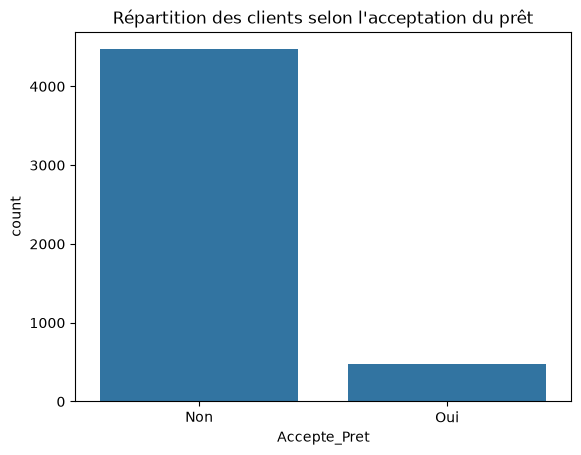

In [15]:
sns.countplot(data=df, x="Accepte_Pret")
plt.title("Répartition des clients selon l'acceptation du prêt")
plt.show()

Taux d'acceptation = Nombre de clients ayant accepté / Nombre total de clients

Ce KPI représente approximativement le taux de conversion historique de la campagne.

Ce taux est égal a 9%

Étape 4 — Analyse univariée

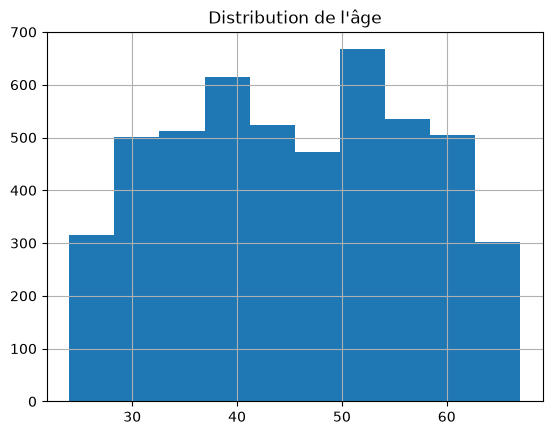

In [16]:
df["Age"].hist()
plt.title("Distribution de l'âge")
plt.show()

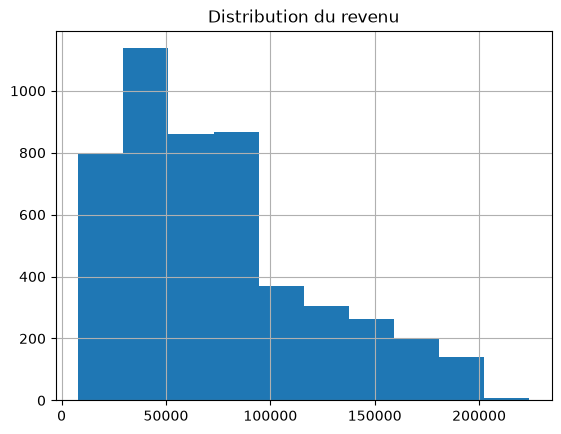

In [17]:
df["Revenu"].hist()
plt.title("Distribution du revenu")
plt.show()

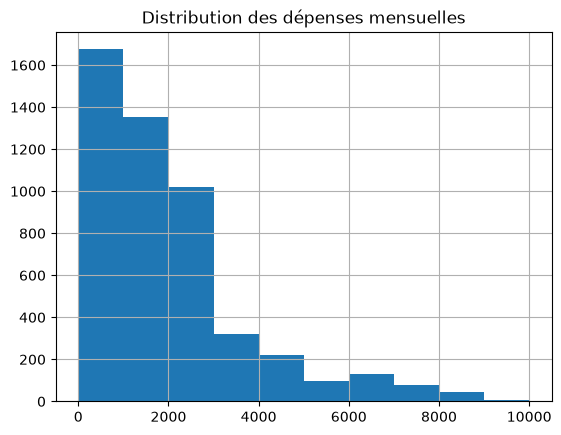

In [18]:
df["Depenses_Mensuelle"].hist()
plt.title("Distribution des dépenses mensuelles")
plt.show()

Étape 5 — Analyse des variables catégorielles

In [19]:
df["Education"].value_counts()

Education
Licence                      2080
Formation professionnelle    1481
Master                       1387
Name: count, dtype: int64

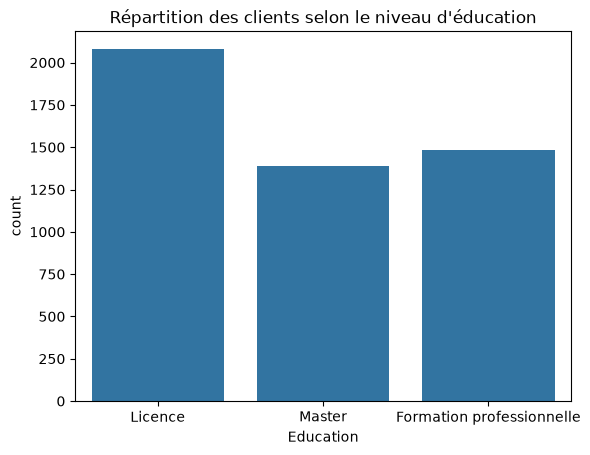

In [20]:
sns.countplot(data=df, x="Education")
plt.title("Répartition des clients selon le niveau d'éducation")
plt.show()

Étape 6 — Analyse bivariée : la partie la plus intéressante

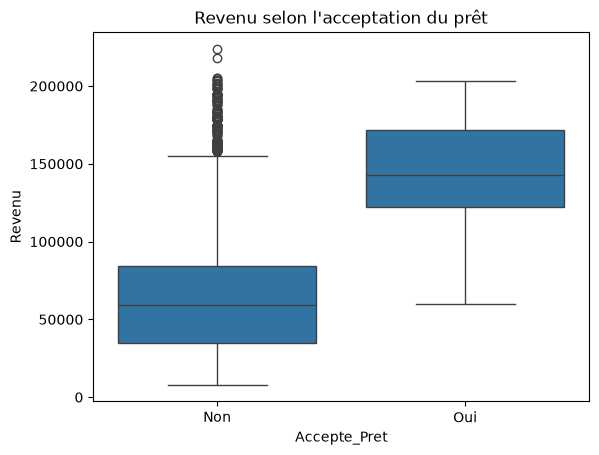

In [21]:
sns.boxplot(data=df, x="Accepte_Pret", y="Revenu")
plt.title("Revenu selon l'acceptation du prêt")
plt.show()

Celon le graphique cidessus, les clients qui acceptent le prêt ont un revenu en moyen significativement plus élevés. Les clients qui acceptent les prets ont un revenus en moyen autour de 150 mille dollars par an tandisque les clients qui ont refusés le pret ont en moyen un revenus autours de 52 mille dollars par an

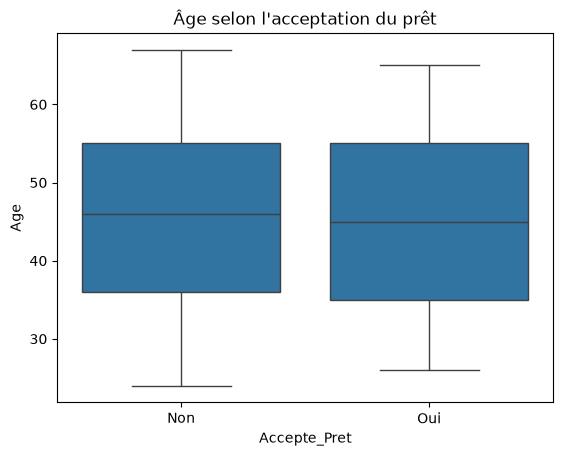

In [22]:
sns.boxplot(data=df, x="Accepte_Pret", y="Age")
plt.title("Âge selon l'acceptation du prêt")
plt.show()

Celon ce graphique l'age n'influence pas sur l'acceptation de pret bancaire

In [23]:
pd.crosstab(
    df["Education"],
    df["Accepte_Pret"],
    normalize="index"
) * 100

Accepte_Pret,Non,Oui
Education,,
Formation professionnelle,86.158001,13.841999
Licence,95.528846,4.471154
Master,86.878154,13.121846


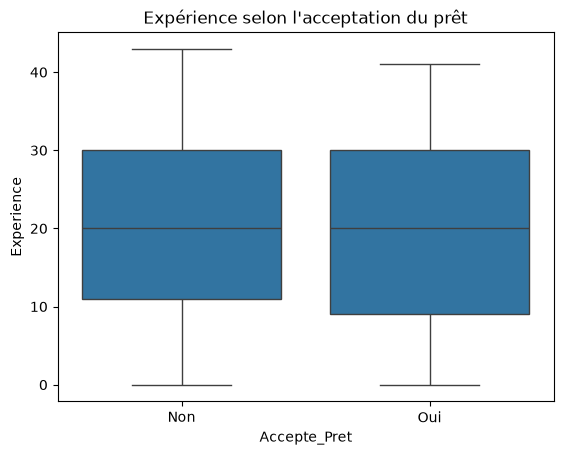

In [24]:
sns.boxplot(data=df, x="Accepte_Pret", y="Experience")
plt.title("Expérience selon l'acceptation du prêt")
plt.show()

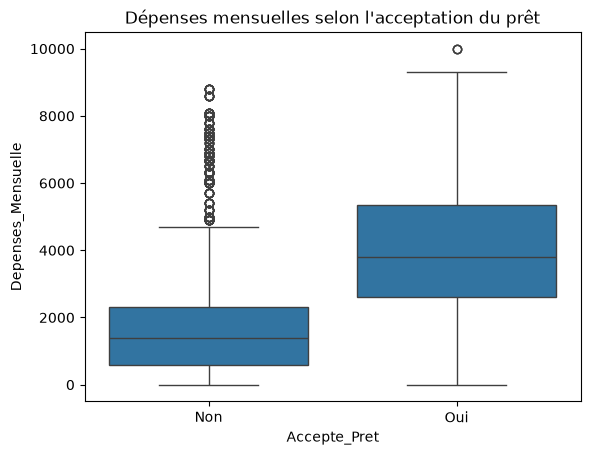

In [25]:
sns.boxplot(data=df, x="Accepte_Pret", y="Depenses_Mensuelle")
plt.title("Dépenses mensuelles selon l'acceptation du prêt")
plt.show()

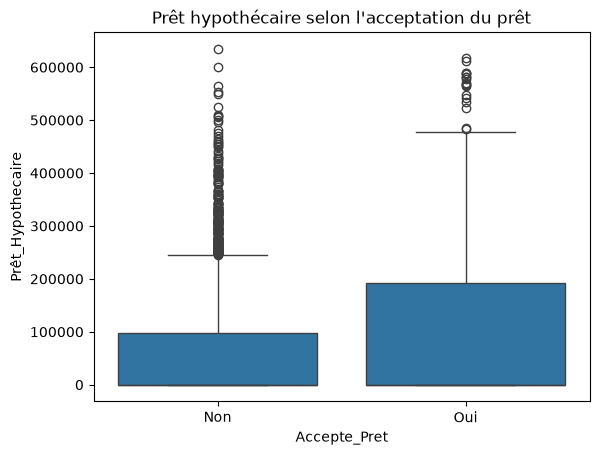

In [26]:
sns.boxplot(data=df, x="Accepte_Pret", y="Prêt_Hypothecaire")
plt.title("Prêt hypothécaire selon l'acceptation du prêt")
plt.show()

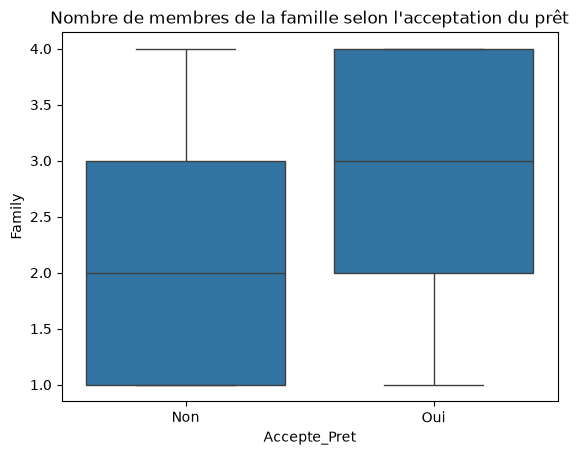

In [27]:
sns.boxplot(data=df, x="Accepte_Pret", y="Family")
plt.title("Nombre de membres de la famille selon l'acceptation du prêt")
plt.show()

In [28]:
pd.crosstab(
    df["Compte_Titre"],
    df["Accepte_Pret"],
    normalize="index"
) * 100

Accepte_Pret,Non,Oui
Compte_Titre,,
Non,90.523466,9.476534
Oui,88.372093,11.627907


In [29]:
from scipy.stats import ttest_ind

groupe_refus = df[df["Accepte_Pret"] == 0]["Revenu"]
groupe_accepte = df[df["Accepte_Pret"] == 1]["Revenu"]

ttest_ind(groupe_accepte, groupe_refus, equal_var=False)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

Celon le tableau precedant, ceux qui ont un compte titre (plus de 11%) accepte beaucoup plus que ceux qui n'en ont pas (plus de 9%)

In [30]:
pd.crosstab(
    df["Certificat_Depot"],
    df["Accepte_Pret"],
    normalize="index"
) * 100

Accepte_Pret,Non,Oui
Certificat_Depot,,
Non,92.681877,7.318123
Oui,53.642384,46.357616


In [31]:
pd.crosstab(
    df["Services_Ligne"],
    df["Accepte_Pret"],
    normalize="index"
) * 100

Accepte_Pret,Non,Oui
Services_Ligne,,
Non,90.521565,9.478435
Oui,90.148951,9.851049


Celon ce tableau precedant, l'acceptation du pret bancaire ne depend pas des service en lignes

In [32]:
pd.crosstab(
    df["CreditCard"],
    df["Accepte_Pret"],
    normalize="index"
) * 100

Accepte_Pret,Non,Oui
CreditCard,,
Non,90.352133,9.647867
Oui,90.171821,9.828179


Celon ce tableau precedant, l'acceptation du pret bancaire ne depend pas des credits Cartes

Étape 8 — Analyse de corrélation

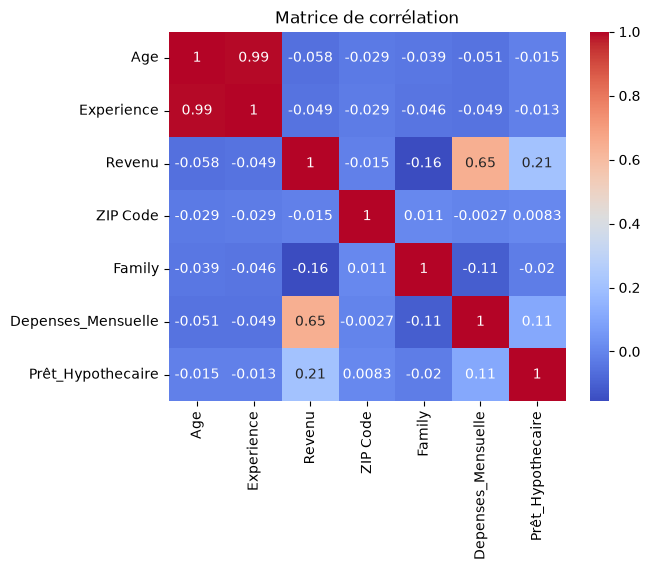

In [33]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["Age", "Experience", "Revenu", "Depenses_Mensuelle"]]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

             Variable        VIF
0                 Age  23.717597
1          Experience  16.892367
2              Revenu   6.037109
3  Depenses_Mensuelle   3.827992


In [35]:
df = df.drop(columns=["Experience"])

In [36]:
X = df[["Age", "Revenu", "Depenses_Mensuelle"]]

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif)

             Variable       VIF
0                 Age  2.992802
1              Revenu  5.625294
2  Depenses_Mensuelle  3.819823


Feature Engineering

In [18]:
import pandas as pd
import numpy as np

df["Categorie_Revenu"] = pd.qcut(
    df["Revenu"],
    q=4,
    labels=["Faible", "Moyen", "Élevé", "Très élevé"]
)

In [38]:
print(df["Categorie_Revenu"].value_counts())

Categorie_Revenu
Faible        1300
Très élevé    1233
Moyen         1224
Élevé         1191
Name: count, dtype: int64


In [19]:
print(
    df.groupby("Categorie_Revenu", observed=True)["Revenu"]
      .agg(["min", "max", "mean"])
)

                    min     max           mean
Categorie_Revenu                              
Faible             8000   39000   25571.538462
Moyen             40000   64000   51120.098039
Élevé             65000   98000   80343.408900
Très élevé        99000  224000  140901.054339


In [52]:
df["Categorie_Age"] = pd.cut(
    df["Age"],
    bins=[0, 29, 49, np.inf],
    labels=["Jeune", "Adulte", "Agée"]
)

In [53]:
print(df["Categorie_Age"].value_counts())

Categorie_Age
Adulte    2504
Agée      2008
Jeune      436
Name: count, dtype: int64


Préparation pour le Machine Learning

Maintenant, il faut séparer :

X = variables explicatives
y = variable cible

Étape 12 — Encodage des variables catégorielles

In [20]:
binary_features = [
    "Accepte_Pret",
    "Compte_Titre",
    "Certificat_Depot",
    "Services_Ligne",
    "CreditCard"
]

In [22]:
for col in binary_features:
    df[col] = df[col].map({
        "Non": 0,
        "Oui": 1
    })
    
print(df[binary_features].head())

    Accepte_Pret  Compte_Titre  Certificat_Depot  Services_Ligne  CreditCard
ID                                                                          
1            NaN           NaN               NaN             NaN         NaN
2            NaN           NaN               NaN             NaN         NaN
3            NaN           NaN               NaN             NaN         NaN
4            NaN           NaN               NaN             NaN         NaN
5            NaN           NaN               NaN             NaN         NaN


Prêt_Hypothecaire

Avec beaucoup de : 0, cela signifie probablement que le client n'a pas de prêt hypothécaire.

C'est une information intéressante.

On pourrait même créer une variable supplémentair

In [23]:
df["A_Pret_Hypothecaire"] = (
    df["Prêt_Hypothecaire"] > 0
).astype(int)

In [24]:
df.head()

,Age,Experience,Revenu,ZIP Code,Family,Depenses_Mensuelle,Education,Prêt_Hypothecaire,Accepte_Pret,Compte_Titre,Certificat_Depot,Services_Ligne,CreditCard,Categorie_Revenu,A_Pret_Hypothecaire
ID,,,,,,,,,,,,,,,
1,25,1,49000,91107,4,1600.0,Licence,0,NaN,NaN,NaN,NaN,NaN,Moyen,0
2,45,19,34000,90089,3,1500.0,Licence,0,NaN,NaN,NaN,NaN,NaN,Faible,0
3,39,15,11000,94720,1,1000.0,Licence,0,NaN,NaN,NaN,NaN,NaN,Faible,0
4,35,9,100000,94112,1,2700.0,Master,0,NaN,NaN,NaN,NaN,NaN,Très élevé,0
5,35,8,45000,91330,4,1000.0,Master,0,NaN,NaN,NaN,NaN,NaN,Moyen,0


Préparation complète du Machine Learning

Voici maintenant la version corrigée de notre pipeline.

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [78]:
X = df[
    [
        "Age",
        "Revenu",
        "Family",
        "Depenses_Mensuelle",
        "Prêt_Hypothecaire",
        "Education",
        "Compte_Titre",
        "Certificat_Depot",
        "Services_Ligne",
        "CreditCard",
        "Categorie_Revenu",
        "Categorie_Age",
        "A_Pret_Hypothecaire"
    ]
]

y = df["Accepte_Pret"]

In [79]:
numeric_features = [
    "Age",
    "Revenu",
    "Family",
    "Depenses_Mensuelle",
    "Prêt_Hypothecaire",
    "Compte_Titre",
    "Certificat_Depot",
    "Services_Ligne",
    "CreditCard",
    "A_Pret_Hypothecaire"
]

categorical_features = [
    "Education",
    "Categorie_Revenu",
    "Categorie_Age"
]

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

Train/Test Split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [82]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (3958, 13)
X_test  : (990, 13)
y_train : (3958,)
y_test  : (990,)


Pour le KNN et Régression Logistique, la standardisation est intéressante.

On va donc utiliser un préprocesseur avec StandardScaler pour standardiser

In [83]:
from sklearn.preprocessing import StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

Modèle 1 — Régression logistique

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

Modèle 2 — KNN

In [85]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

Modèle 3 — Decision Tree

In [86]:
from sklearn.tree import DecisionTreeClassifier

model_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

Modèle 4 — Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

Mettre les modèles dans un dictionnaire

In [88]:
models = {
    "Régression Logistique": model_logistic,
    "KNN": model_knn,
    "Decision Tree": model_tree,
    "Random Forest": model_rf
}

print(models.keys())

dict_keys(['Régression Logistique', 'KNN', 'Decision Tree', 'Random Forest'])


Entraîner les modèles

In [89]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{name} : entraîné avec succès")

Régression Logistique : entraîné avec succès
KNN : entraîné avec succès
Decision Tree : entraîné avec succès
Random Forest : entraîné avec succès


Étape 15 — Évaluer les modèles

On va utiliser plusieurs métriques :

Accuracy
Precision
Recall
F1-score
ROC-AUC

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    # Prédictions
    y_pred = model.predict(X_test)

    # Probabilités
    y_proba = model.predict_proba(X_test)[:, 1]

    # Métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Modèle": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

In [92]:
results_df = pd.DataFrame(results)

print(results_df)

                  Modèle  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Régression Logistique  0.961616   0.822222  0.770833  0.795699  0.976242
1                    KNN  0.958586   0.923077  0.625000  0.745342  0.979260
2          Decision Tree  0.984848   0.909091  0.937500  0.923077  0.963716
3          Random Forest  0.987879   0.946809  0.927083  0.936842  0.998310


In [93]:
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print(results_df.round(4))

                  Modèle  Accuracy  Precision  Recall  F1-score  ROC-AUC
3          Random Forest    0.9879     0.9468  0.9271    0.9368   0.9983
1                    KNN    0.9586     0.9231  0.6250    0.7453   0.9793
0  Régression Logistique    0.9616     0.8222  0.7708    0.7957   0.9762
2          Decision Tree    0.9848     0.9091  0.9375    0.9231   0.9637


Étape 16 — Matrices de confusion

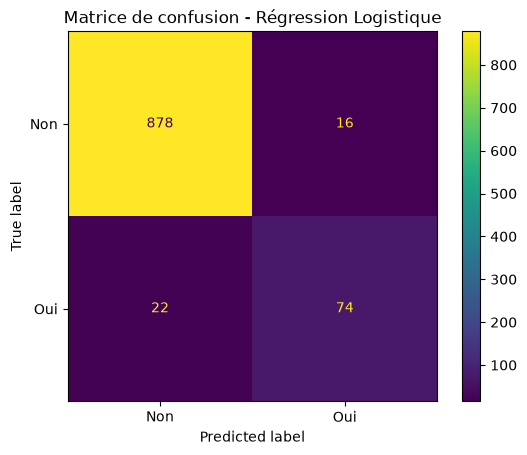

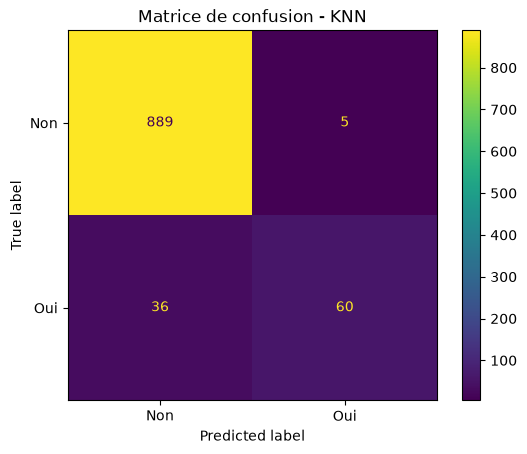

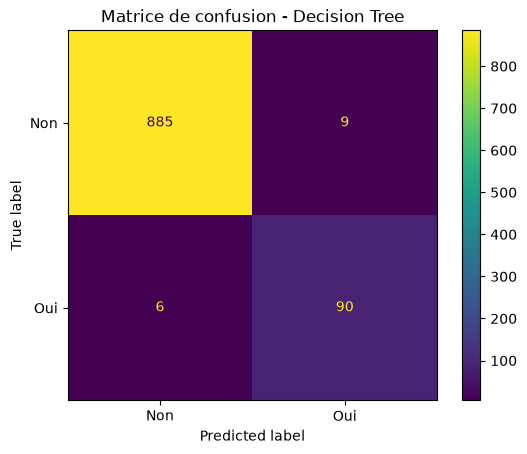

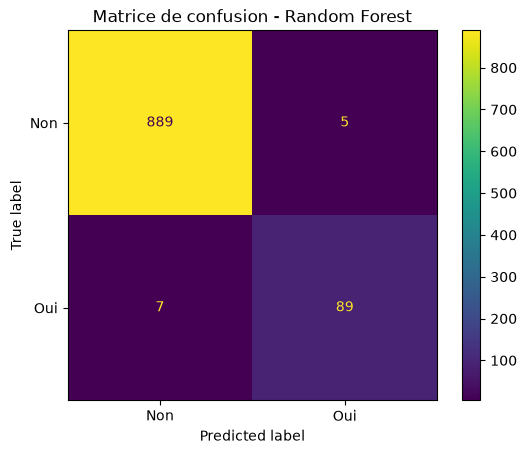

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non", "Oui"]
    )

    disp.plot()

    plt.title(f"Matrice de confusion - {name}")
    plt.show()

Étape 18 — Optimisation

In [96]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

GridSearchCV

In [97]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [98]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

Voir les meilleurs paramètres

In [99]:
print("Meilleurs hyperparamètres :", grid_search.best_params_)

Meilleurs hyperparamètres : {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


Meilleur score de validation croisée

In [100]:
print(
    "Meilleur ROC-AUC CV :",
    grid_search.best_score_
)

Meilleur ROC-AUC CV : 0.9972856366423171


In [101]:
# Récupérer le modèle optimisé

best_model = grid_search.best_estimator_


# Réévaluer le modèle optimisé
y_pred_best = best_model.predict(X_test)

y_proba_best = best_model.predict_proba(X_test)[:, 1]

In [102]:
accuracy_best = accuracy_score(
    y_test,
    y_pred_best
)

precision_best = precision_score(
    y_test,
    y_pred_best
)

recall_best = recall_score(
    y_test,
    y_pred_best
)

f1_best = f1_score(
    y_test,
    y_pred_best
)

roc_auc_best = roc_auc_score(
    y_test,
    y_proba_best
)

In [103]:
print("Performance du modèle optimisé")
print("--------------------------------")
print(f"Accuracy  : {accuracy_best:.4f}")
print(f"Precision : {precision_best:.4f}")
print(f"Recall    : {recall_best:.4f}")
print(f"F1-score  : {f1_best:.4f}")
print(f"ROC-AUC   : {roc_auc_best:.4f}")

Performance du modèle optimisé
--------------------------------
Accuracy  : 0.9869
Precision : 0.9560
Recall    : 0.9062
F1-score  : 0.9305
ROC-AUC   : 0.9984


Comparer avant/après optimisation

In [104]:
print("Avant optimisation :")
print(
    results_df[
        results_df["Modèle"] == "Random Forest"
    ]
)

print("\nAprès optimisation :")
print(f"Accuracy  : {accuracy_best:.4f}")
print(f"Precision : {precision_best:.4f}")
print(f"Recall    : {recall_best:.4f}")
print(f"F1-score  : {f1_best:.4f}")
print(f"ROC-AUC   : {roc_auc_best:.4f}")

Avant optimisation :
          Modèle  Accuracy  Precision    Recall  F1-score  ROC-AUC
3  Random Forest  0.987879   0.946809  0.927083  0.936842  0.99831

Après optimisation :
Accuracy  : 0.9869
Precision : 0.9560
Recall    : 0.9062
F1-score  : 0.9305
ROC-AUC   : 0.9984


Étape 19 — Feature Importance

Puisque nous utilisons Random Forest, on peut récupérer l'importance des variables.

Le modèle optimisé est un Pipeline.

In [106]:
# On récupère donc le modèle :
rf_final = best_model.named_steps["model"]

# Puis le préprocesseur :
preprocessor_final = best_model.named_steps["preprocessor"]

# Récupérer les noms des variables après encodage :
feature_names = (
    preprocessor_final
    .get_feature_names_out()
)

# On peut maintenant créer un DataFrame avec les importances des variables :
importances = rf_final.feature_importances_

# Créer un DataFrame :
feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
})

# Trier par importance décroissante :
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Afficher les 15 plus importantes :
print(
    feature_importance.head(15).round(4)
)

                                    Variable  Importance
8                            numeric__Revenu      0.2462
0             categorical__Education_Licence      0.1918
9                            numeric__Family      0.1268
10               numeric__Depenses_Mensuelle      0.1259
3   categorical__Categorie_Revenu_Très élevé      0.1047
13                 numeric__Certificat_Depot      0.0503
1              categorical__Education_Master      0.0475
7                               numeric__Age      0.0329
11                numeric__Prêt_Hypothecaire      0.0281
4        categorical__Categorie_Revenu_Élevé      0.0075
15                       numeric__CreditCard      0.0071
2        categorical__Categorie_Revenu_Moyen      0.0071
14                   numeric__Services_Ligne      0.0064
5            categorical__Categorie_Age_Agée      0.0064
12                     numeric__Compte_Titre      0.0041


Graphique des variables importantes

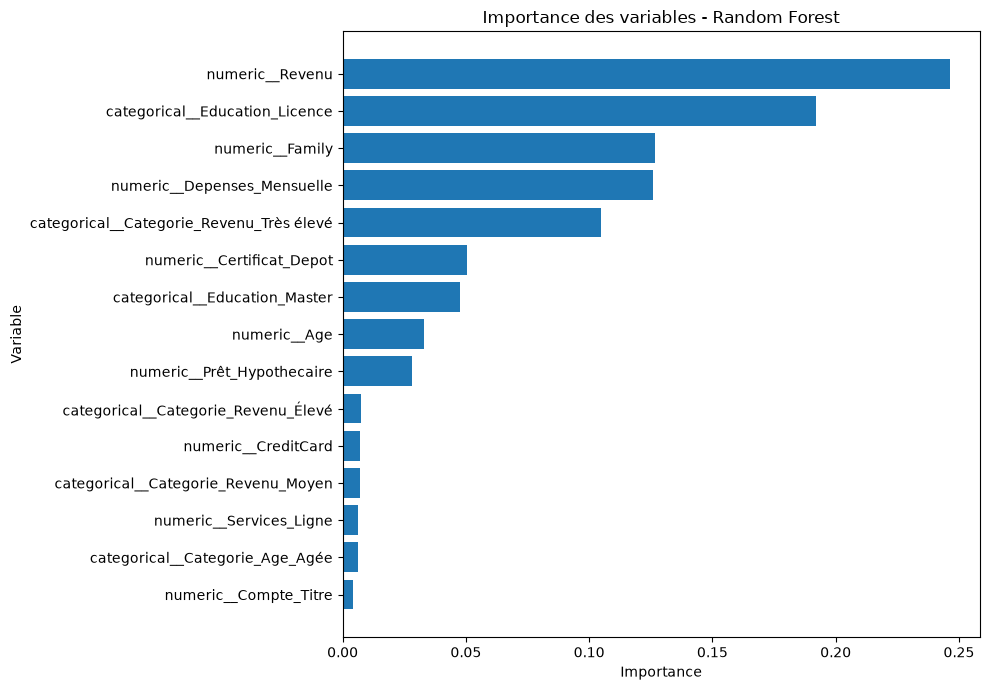

In [107]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Variable"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables - Random Forest")

plt.tight_layout()
plt.show()

Étape 20 — Transformer le modèle en outil marketing

C'est une partie très importante de ton projet.

l peut donner une probabilité d'acceptation.

Par exemple :
Client A → 92 %
Client B → 78 %
Client C → 54 %
Client D → 18 %

In [108]:
# Calculer la probabilité
probabilites = best_model.predict_proba(X_test)[:, 1]

# Créer une copie :
clients_test = X_test.copy()

clients_test["Probabilite_Acceptation"] = probabilites


# Créer des segments marketing
def segment_marketing(probabilite):

    if probabilite >= 0.80:
        return "Très forte probabilité"

    elif probabilite >= 0.60:
        return "Forte probabilité"

    elif probabilite >= 0.40:
        return "Probabilité moyenne"

    else:
        return "Faible probabilité"

# Appliquer :
clients_test["Segment_Marketing"] = (
    clients_test["Probabilite_Acceptation"]
    .apply(segment_marketing)
)

# Afficher :
print(
    clients_test[
        [
            "Probabilite_Acceptation",
            "Segment_Marketing"
        ]
    ].head(20)
)


# Créer une recommandation marketing
def recommandation(probabilite):

    if probabilite >= 0.80:
        return "Contacter prioritairement"

    elif probabilite >= 0.60:
        return "Proposer une offre personnalisée"

    elif probabilite >= 0.40:
        return "Campagne de relance"

    else:
        return "Ne pas cibler prioritairement"

clients_test["Recommandation"] = (
    clients_test["Probabilite_Acceptation"]
    .apply(recommandation)
)

      Probabilite_Acceptation   Segment_Marketing
ID                                               
3386                 0.000106  Faible probabilité
3789                 0.005244  Faible probabilité
3519                 0.028708  Faible probabilité
192                  0.000242  Faible probabilité
2873                 0.000202  Faible probabilité
1458                 0.000122  Faible probabilité
3146                 0.794886   Forte probabilité
2972                 0.000000  Faible probabilité
3375                 0.000007  Faible probabilité
120                  0.078947  Faible probabilité
4510                 0.000007  Faible probabilité
3929                 0.000007  Faible probabilité
3531                 0.000000  Faible probabilité
3874                 0.000000  Faible probabilité
269                  0.015077  Faible probabilité
575                  0.002488  Faible probabilité
3124                 0.000065  Faible probabilité
604                  0.000065  Faible probabilité


Analyse marketing globale

Tu peux compter les clients par segment :

Segment_Marketing
Faible probabilité        892
Très forte probabilité     71
Forte probabilité          14
Probabilité moyenne        13
Name: count, dtype: int64


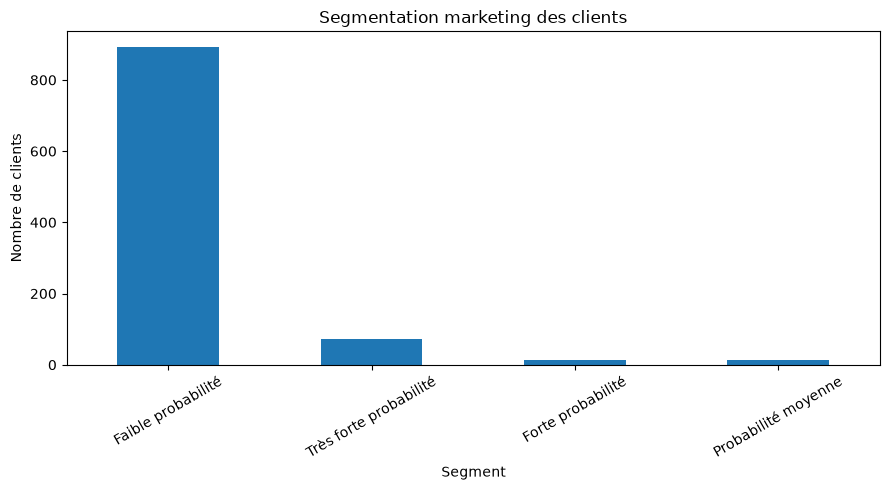

In [109]:
# compter les clients par segment :
print(
    clients_test["Segment_Marketing"]
    .value_counts()
)

# Graphique :
clients_test["Segment_Marketing"].value_counts().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Segmentation marketing des clients")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Étape 21 — Sauvegarder le modèle

sauvegarder le modèle optimisé, et pas le modèle initial.

In [111]:
import joblib

In [113]:
joblib.dump(
    best_model,
    "modele_thera_bank.pkl"
)

['modele_thera_bank.pkl']

Très important : sauvegarder les seuils de revenu, Age et 

Il y a un problème dans notre Feature Engineering actuel.

In [112]:
# recuperer les seuils de revenu
df["Categorie_Revenu"], revenu_bins = pd.qcut(
    df["Revenu"],
    q=4,
    labels=[
        "Faible",
        "Moyen",
        "Élevé",
        "Très élevé"
    ],
    retbins=True
)

# Puis sauvegarder les seuils :
joblib.dump(
    revenu_bins,
    "seuils_revenu.pkl"
)

# Pour l'Age
df["Categorie_Age"], age_bins = pd.cut(
    df["Age"],
    bins=[0, 29, 49, np.inf],
    labels=["Jeune", "Adulte", "Agée"],
    retbins=True
)
joblib.dump(age_bins, "seuils_age.pkl")

# Pour le Prêt Hypothécaire
seuil_pret = 0
df["A_Pret_Hypothecaire"] = (
    df["Prêt_Hypothecaire"] > seuil_pret
).astype(int)
joblib.dump(seuil_pret, "seuils_pret_hypothecaire.pkl")


['seuils_pret_hypothecaire.pkl']

In [114]:
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

# ============================================================
# 1. Meilleur modèle : Random Forest
# ============================================================


# Si tu as optimisé Random Forest avec GridSearchCV,
# utilise plutôt :
best_model = grid_search.best_estimator_


# ============================================================
# 2. Prédictions
# ============================================================

y_pred = best_model.predict(X_test)

# Probabilité de la classe positive "Oui"
y_proba = best_model.predict_proba(X_test)[:, 1]


# ============================================================
# 3. Calcul des métriques
# ============================================================

auc = roc_auc_score(y_test, y_proba)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_pred)


# ============================================================
# 4. Courbe ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)


# ============================================================
# 5. Transformer les résultats en listes compatibles JSON
# ============================================================

metrics = {
    "model": "Random Forest",

    "AUC": round(float(auc), 4),

    "precision": round(float(precision), 4),

    "recall": round(float(recall), 4),

    "F1": round(float(f1), 4),

    "confusion_matrix": cm.tolist(),

    "roc_curve": {
        "fpr": fpr.tolist(),
        "tpr": tpr.tolist(),
        "thresholds": thresholds.tolist()
    }
}


# ============================================================
# 6. Enregistrer metrics.json
# ============================================================

with open(
    "metrics.json",
    "w",
    encoding="utf-8"
) as fichier:

    json.dump(
        metrics,
        fichier,
        indent=4,
        ensure_ascii=False
    )


print("✅ metrics.json créé avec succès !")

✅ metrics.json créé avec succès !
